In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import recordlinkage
import random
from recordlinkage.preprocessing import phonetic

In [2]:
df_sales = pd.read_csv('data/purchases.csv')
df_crm = pd.read_csv('data/crm_export.csv')
df_customer_db = pd.read_csv('data/customer_database.csv')

The desire outcome should be a **single dataset** representing your customer data model
Data will come from the three sources provided, and you will need to consolidate and deduplicate accordingly.
This data model should be structured so that all the logic to define customers is already in place, and answering the quetion "How many customers do we have?" should be done as simply as counting rows.

In [3]:
print(f'sales number of rows: {df_sales.shape[0]}')
print(f'crm number of rows: {df_crm.shape[0]}')
print(f'customer database (Ecommerce)number of rows: {df_customer_db.shape[0]}')

sales number of rows: 71519
crm number of rows: 7825
customer database (Ecommerce)number of rows: 23476


In [4]:
df_crm.sample(5)

,customer_id,first_name,surname,postcode,age
7514,18523,Toby,Wright,RG108UR,49
83,6648,Jayden,Bailey,HR559UN,48
2528,20640,Sarah,Cooper,RG877SX,57
5868,20725,Grace,Carter,RG910HN,31
1001,12648,Sophie,Cook,M914EF,56


In [5]:
df_customer_db.sample(5)

,customer_id,first_name,surname,postcode,age
2207,31969,Keira,Harrison,PO200HG,70
10998,13519,Sophie,Jones,NW347EE,8
4000,22539,Samuel,Watson,SO751EH,2
17673,10337,Thomas,Murray,M192ER,83
17867,22379,Aaron,Thompson,SO598XD,71


In [6]:
df_sales.sample(5)

,event_time,product_id,category_id,category_code,brand,price,session_id,customer_id,guest_first_name,guest_surname,guest_postcode
443,2022-10-01 07:09:05+00:00,1004739,2053013555631882655,electronics.smartphone,xiaomi,197.52,0a7e39bc-a8a2-4c7a-9197-c524691c7c62,,PAIGE,EVANS,M685ZF
2541,2022-10-02 08:34:54+00:00,28715643,2053013565069067197,apparel.shoes.keds,adidas,102.94,27ea1358-a9ec-42f9-a2db-4b63cefb8d9f,11209.0,,,
67752,2022-10-30 03:44:32+00:00,1005002,2053013555631882655,electronics.smartphone,huawei,244.51,a43e3252-11b3-49a2-aaae-9980e6b494be,,GEORGE,RICHARDSON,SW813UN
12089,2022-10-06 15:46:50+00:00,34200099,2061717948493463814,,emsa,12.84,7bd655bf-7bdc-4c54-9c14-10e3336ac99b,,CHARLOTTE,CAMPBELL,EX86QS
58941,2022-10-25 18:06:52+00:00,1004833,2053013555631882655,electronics.smartphone,samsung,170.31,11a8d7b5-5139-44d2-a4a8-96cb532d5b96,16283.0,,,


### Exploring the data

In [7]:
df_crm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7825 entries, 0 to 7824
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7825 non-null   int64 
 1   first_name   7825 non-null   object
 2   surname      7825 non-null   object
 3   postcode     7825 non-null   object
 4   age          7825 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 305.8+ KB


In [8]:
df_customer_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23476 entries, 0 to 23475
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  23476 non-null  int64 
 1   first_name   23476 non-null  object
 2   surname      23476 non-null  object
 3   postcode     23476 non-null  object
 4   age          23476 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 917.2+ KB


In [9]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71519 entries, 0 to 71518
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   event_time                               71519 non-null  object 
 1    product_id                              71519 non-null  int64  
 2    category_id                             71519 non-null  int64  
 3    category_code                           71519 non-null  object 
 4    brand                                   71519 non-null  object 
 5    price                                   71519 non-null  float64
 6    session_id                              71519 non-null  object 
 7    customer_id                             71519 non-null  object 
 8    guest_first_name                        71519 non-null  object 
 9    guest_surname                           71519 non-null  object 
 10   guest_postcode                          71519

In [10]:
# Number of purchases made as guest
df_sales[' customer_id'].isnull().sum() 

np.int64(0)

First I am going to deduplicate the possible registers in the ecommerce_db and in crm_db

### Preprocessing

In [11]:
df_crm['first_name_cleaned'] = df_crm['first_name'].str.strip().str.title()
df_crm['surname_cleaned'] = df_crm['surname'].str.strip().str.title()
df_crm['postcode_cleaned'] = df_crm['postcode'].str.strip()
df_crm.head(3)

,customer_id,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned
0,29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT
1,27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX
2,7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA


In [12]:
df_customer_db['first_name_cleaned'] = df_customer_db['first_name'].str.strip().str.title()
df_customer_db['surname_cleaned'] = df_customer_db['surname'].str.strip().str.title()
df_customer_db['postcode_cleaned'] = df_customer_db['postcode'].str.strip()
df_customer_db.head(3)

,customer_id,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned
0,1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ
1,24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX
2,14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU


In [13]:
# Phonetic encoding
df_crm['phonetic_first_name'] = phonetic(df_crm['first_name_cleaned'], 'soundex')
df_crm['phonetic_surname'] = phonetic(df_crm['surname_cleaned'], 'soundex')
# Adding a initial colunmn
df_crm['initials'] =  df_crm['first_name_cleaned'].str[0] + df_crm['surname_cleaned'].str[0]
df_crm = df_crm.set_index('customer_id')
df_crm.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER


In [14]:
# Phonetic encodig
df_customer_db['phonetic_first_name'] = phonetic(df_customer_db['first_name_cleaned'], 'soundex')
df_customer_db['phonetic_surname'] = phonetic(df_customer_db['surname_cleaned'], 'soundex')
# Adding a initial colunmn
df_customer_db['initials'] =  df_customer_db['first_name_cleaned'].str[0] + df_customer_db['surname_cleaned'].str[0]
df_customer_db = df_customer_db.set_index('customer_id')
df_customer_db.head(3)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK


### Indexing

In [15]:
indices = recordlinkage.Index()
indices.block('initials')
possible_indexes_matching = indices.index(df_customer_db, df_crm)
possible_indexes_matching

MultiIndex([( 1641, 21710),
            ( 1641, 27643),
            ( 1641,  8174),
            ( 1641,  1641),
            ( 1641, 32623),
            ( 1641, 23330),
            ( 1641, 27768),
            ( 1641, 29180),
            ( 1641, 21330),
            ( 1641,  9695),
            ...
            (29494, 15904),
            (29494, 18273),
            (29494, 21772),
            (29494,  1886),
            (29494,  4201),
            (29494,  8108),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918)],
           names=['customer_id_1', 'customer_id_2'], length=861840)

In [16]:
df_crm.loc[10918]

first_name               Ruby
surname                  Cook
postcode               M432ZZ
age                        35
first_name_cleaned       Ruby
surname_cleaned          Cook
postcode_cleaned       M432ZZ
phonetic_first_name      R100
phonetic_surname         C200
initials                   RC
Name: 10918, dtype: object

In [17]:
df_customer_db.loc[29494]

first_name               Reece
surname                Chafhan
postcode               SO433HB
age                         41
first_name_cleaned       Reece
surname_cleaned        Chafhan
postcode_cleaned       SO433HB
phonetic_first_name       R200
phonetic_surname          C150
initials                    RC
Name: 29494, dtype: object

### Comparing

In [18]:
df_crm.head(2)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO


In [19]:
df_customer_db.head(2)

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY


In [20]:
#levenshtein for postcode
#jarowinkler for names
comparisons = recordlinkage.Compare()
comparisons.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
comparisons.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
comparisons.exact('age', 'age', label='age' )
comparisons.string('postcode', 'postcode', method='levenshtein', label='postcode')
comparisons.exact('phonetic_first_name', 'phonetic_first_name', label='phonetic_first_name')
comparisons.exact('phonetic_surname', 'phonetic_surname', label='phonetic_surname')
comparison_output = comparisons.compute(possible_indexes_matching, df_customer_db, df_crm)
comparison_output

first_name   surname  age  postcode  \
customer_id_1 customer_id_2                                        
1641          21710            0.666667  0.737500    0  0.142857   
              27643            0.472222  0.950000    0  0.285714   
              8174             0.472222  0.625000    0  0.000000   
              1641             1.000000  1.000000    1  1.000000   
              32623            0.633333  0.569444    0  0.142857   
...                                 ...       ...  ...       ...   
29494         8108             0.600000  0.523810    0  0.000000   
              2651             0.483333  0.511905    0  0.142857   
              7086             0.483333  0.436508    0  0.000000   
              6418             0.760000  0.511905    0  0.000000   
              10918            0.483333  0.464286    0  0.285714   

                             phonetic_first_name  phonetic_surname  
customer_id_1 customer_id_2                                         
1641          21710                            0                 0  
              27643                            0                 1  
              8174                             0                 0  
              1641                             1                 1  
              32623                            1                 0  
...                                          ...               ...  
29494         8108                             0                 0  
              2651                             0                 0  
              7086                             0                 0  
              6418                             0                 0  
              10918                            0                 0  

[861840 rows x 6 columns]

### Classification

In [21]:
# Unsupervised
# ECMClassifier

ecm1 = recordlinkage.ECMClassifier(init='jaro', binarize=0.5, max_iter=100)
ecm1.fit(comparison_output)
matching_unsupervised_output1 = ecm1.predict(comparison_output)
matching_unsupervised_output1

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8641)

In [22]:
# Unsupervised
# ECMClassifier

ecm2 = recordlinkage.ECMClassifier(init='jaro', binarize=0.53, max_iter=100)
ecm2.fit(comparison_output)
matching_unsupervised_output2 = ecm2.predict(comparison_output)
matching_unsupervised_output2

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8630)

In [23]:
diff_indexes = matching_unsupervised_output1.difference(matching_unsupervised_output2)
print(diff_indexes)
print(len(diff_indexes))

MultiIndex([( 6052, 29217),
            (18263, 18284),
            (20923, 20952),
            (22185, 21702),
            (22768, 28437),
            (23918, 23917),
            (23941, 13111),
            (27535, 21702),
            (29374, 23917),
            (29827, 13111),
            (29884, 18284)],
           names=['customer_id_1', 'customer_id_2'])
11


Although going from 0.5 to 0.53 only removes 11 pairs out of 8641, it does not mean a significant increase in the correct pairing of the indexes. I will use this 0.53 and, based on the pairings that this value gives me, I will work.

In [24]:
print(df_customer_db.loc[24971])
print('---' * 12)
print(df_crm.loc[30781])

first_name             Alexander
surname                  Roberts
postcode                 SW500HW
age                           85
first_name_cleaned     Alexander
surname_cleaned          Roberts
postcode_cleaned         SW500HW
phonetic_first_name         A425
phonetic_surname            R163
initials                      AR
Name: 24971, dtype: object
------------------------------------
first_name             Alexander
surname                  Roberts
postcode                 NW500AT
age                           41
first_name_cleaned     Alexander
surname_cleaned          Roberts
postcode_cleaned         NW500AT
phonetic_first_name         A425
phonetic_surname            R163
initials                      AR
Name: 30781, dtype: object


In [25]:
print(df_customer_db.loc[7276])
print('---' * 12)
print(df_crm.loc[7319])

first_name                Ella
surname                  Green
postcode               HR802JT
age                         95
first_name_cleaned        Ella
surname_cleaned          Green
postcode_cleaned       HR802JT
phonetic_first_name       E400
phonetic_surname          G650
initials                    EG
Name: 7276, dtype: object
------------------------------------
first_name                Ella
surname                  Green
postcode               HR802JU
age                         96
first_name_cleaned        Ella
surname_cleaned          Green
postcode_cleaned       HR802JU
phonetic_first_name       E400
phonetic_surname          G650
initials                    EG
Name: 7319, dtype: object


Setting the threshold of age to remove false positive matches when the difference of ages is too much

In [26]:
ages_differences = abs(df_customer_db.loc[matching_unsupervised_output2.get_level_values(0), 'age'].values - df_crm.loc[matching_unsupervised_output2.get_level_values(1), 'age'].values)
ages_differences

array([ 0, 65,  0, ..., 35,  0,  0], shape=(8630,))

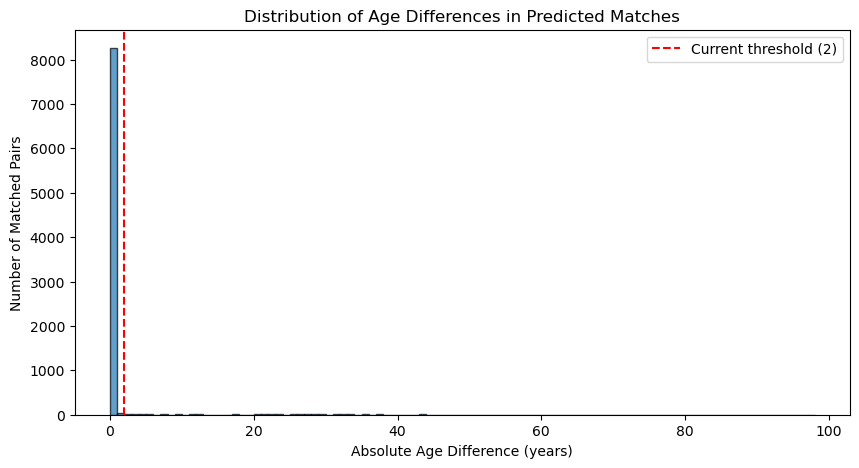

In [27]:
plt.figure(figsize=(10,5))
plt.hist(ages_differences, bins=range(0, max(ages_differences) +2), edgecolor='black', alpha=0.7)
plt.xlabel('Absolute Age Difference (years)')
plt.ylabel('Number of Matched Pairs')
plt.title('Distribution of Age Differences in Predicted Matches')
plt.axvline(x=2, color='red', linestyle='--', label='Current threshold (2)')
plt.legend()
plt.show()

Through the histogram we can see if there is a specific 'gap' where the pair matches difference of ages becomes too much and see if there a specific pattern

In [28]:
# Adding summary stats
print(f'Median: {np.median(ages_differences):.2f}')
print(f'90th percentile: {np.percentile(ages_differences, 90):.2f}')
print(f'95th percenticle: {np.percentile(ages_differences, 95):.2f}')
print(f'96th percenticle: {np.percentile(ages_differences, 96):.2f}')
print(f'97th percenticle: {np.percentile(ages_differences, 97):.2f}')
print(f'98th percenticle: {np.percentile(ages_differences, 98):.2f}')

Median: 0.00
90th percentile: 0.00
95th percenticle: 0.00
96th percenticle: 1.00
97th percenticle: 9.00
98th percenticle: 23.00


In [29]:
bool_age_arr = abs(df_customer_db.loc[matching_unsupervised_output2.get_level_values(0), 'age'].values - df_crm.loc[matching_unsupervised_output2.get_level_values(1), 'age'].values) > 2

The jump from 1 to 9 between the 96th and 97th percentile is the gap we were looking for. It tells you:

  - 96% of matches have age diff ≤ 1
  - Then it jumps straight to 9 — no pairs sitting at 2, 3, 4, 5, 6, 7, 8

  That's a clear natural separation. So a threshold of > 2 or > 3 is much more data-driven than the original 5. Your reasoning is solid

In [30]:
matching_unsupervised_output2[bool_age_arr]

MultiIndex([(24796, 26110),
            (24971, 30781),
            (25231, 29740),
            (26530, 31882),
            (26195, 26196),
            (29095, 21037),
            (21892, 32453),
            (14369, 14030),
            (32363, 11037),
            (14030, 29985),
            ...
            (21756, 24719),
            ( 7934,  7935),
            ( 7934,  7936),
            ( 7242,  7239),
            (17508, 17509),
            ( 6321, 30978),
            ( 6321,  6323),
            ( 1127,  3244),
            (17390, 28453),
            ( 5982,  6496)],
           names=['customer_id_1', 'customer_id_2'], length=307)

In [31]:
print(df_customer_db.loc[24796])
print('---' * 12)
print(df_crm.loc[26110])

first_name              Maisie
surname                  Young
postcode               SW433XX
age                         16
first_name_cleaned      Maisie
surname_cleaned          Young
postcode_cleaned       SW433XX
phonetic_first_name       M200
phonetic_surname          Y520
initials                    MY
Name: 24796, dtype: object
------------------------------------
first_name              Maisie
surname                  Young
postcode               SW937XN
age                         81
first_name_cleaned      Maisie
surname_cleaned          Young
postcode_cleaned       SW937XN
phonetic_first_name       M200
phonetic_surname          Y520
initials                    MY
Name: 26110, dtype: object


In [32]:
matching_unsupervised_output2[matching_unsupervised_output2.get_level_values(0) == 24796]

MultiIndex([(24796, 26110),
            (24796, 24796)],
           names=['customer_id_1', 'customer_id_2'])

In [33]:
df_crm.loc[24796]

first_name              Maisie
surname                  Young
postcode               SW433XX
age                         16
first_name_cleaned      Maisie
surname_cleaned          Young
postcode_cleaned       SW433XX
phonetic_first_name       M200
phonetic_surname          Y520
initials                    MY
Name: 24796, dtype: object

In [34]:
df_customer_db.loc[24796]

first_name              Maisie
surname                  Young
postcode               SW433XX
age                         16
first_name_cleaned      Maisie
surname_cleaned          Young
postcode_cleaned       SW433XX
phonetic_first_name       M200
phonetic_surname          Y520
initials                    MY
Name: 24796, dtype: object

In [35]:
df_crm.loc[26110] # What will happen with this register?

first_name              Maisie
surname                  Young
postcode               SW937XN
age                         81
first_name_cleaned      Maisie
surname_cleaned          Young
postcode_cleaned       SW937XN
phonetic_first_name       M200
phonetic_surname          Y520
initials                    MY
Name: 26110, dtype: object

In [36]:
matching_unsupervised_output2[matching_unsupervised_output2.get_level_values(1)==26110]

MultiIndex([(24796, 26110)],
           names=['customer_id_1', 'customer_id_2'])

In [37]:
matching_unsupervised_output2[matching_unsupervised_output2.get_level_values(0)==26110]

MultiIndex([], names=['customer_id_1', 'customer_id_2'])

In [38]:
# Removing pairs mathces with mote than 2 years of difference
ages_cleaned_matches = matching_unsupervised_output2[~bool_age_arr]
ages_cleaned_matches

MultiIndex([( 1641,  1641),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            (28332,  4556),
            (28332, 28332),
            ...
            (30532, 26494),
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8323)

In [39]:
print(f'Removed: {bool_age_arr.sum()}')
print(f'After age filtered: {len(ages_cleaned_matches)}')

Removed: 307
After age filtered: 8323


In [40]:
for x in range(5):
    random_index = random.randrange(len(ages_cleaned_matches))
    idx1, idx2 = ages_cleaned_matches[random_index]
    print(df_customer_db.loc[idx1])
    print(df_crm.loc[idx2])
    print('---' * 12)


first_name                Isla
surname                 Rogers
postcode               LS806XB
age                         35
first_name_cleaned        Isla
surname_cleaned         Rogers
postcode_cleaned       LS806XB
phonetic_first_name       I240
phonetic_surname          R262
initials                    IR
Name: 9292, dtype: object
first_name                Isla
surname                 Rogers
postcode               LS806XB
age                         35
first_name_cleaned        Isla
surname_cleaned         Rogers
postcode_cleaned       LS806XB
phonetic_first_name       I240
phonetic_surname          R262
initials                    IR
Name: 9292, dtype: object
------------------------------------
first_name               Isaac
surname                  Scott
postcode               DE352AN
age                         96
first_name_cleaned       Isaac
surname_cleaned          Scott
postcode_cleaned       DE352AN
phonetic_first_name       I220
phonetic_surname          S300
initials    

In [41]:
df_customer_db.loc[ages_cleaned_matches.get_level_values(0), 'postcode'].values

array(['DE456EZ', 'SW433XX', 'NW49TU', ..., 'SO527ST', 'SO976NU',
       'EX709AR'], shape=(8323,), dtype=object)

In [42]:
df_crm.loc[ages_cleaned_matches.get_level_values(1), 'postcode'].values

array(['DE456EZ', 'SW433XX', 'NW49TU', ..., 'SO527ST', 'SO976NU',
       'EX709AR'], shape=(8323,), dtype=object)

In [43]:
postcode_matches = df_customer_db.loc[ages_cleaned_matches.get_level_values(0), 'postcode'].values == df_crm.loc[ages_cleaned_matches.get_level_values(1), 'postcode'].values

In [44]:
phonetic_surname_matches = df_customer_db.loc[ages_cleaned_matches.get_level_values(0), 'phonetic_surname'].values == df_crm.loc[ages_cleaned_matches.get_level_values(1), 'phonetic_surname'].values

In [45]:
phonetic_first_name_matches = df_customer_db.loc[ages_cleaned_matches.get_level_values(0), 'phonetic_first_name'].values == df_crm.loc[ages_cleaned_matches.get_level_values(1), 'phonetic_first_name'].values

In [46]:
bool_mask_postcode_names_diff =  (~postcode_matches) & (~phonetic_surname_matches | ~phonetic_first_name_matches)
ages_cleaned_matches[bool_mask_postcode_names_diff]

MultiIndex([( 1177,  2527),
            (14552, 25011),
            ( 9487,  9531),
            (16629, 16766),
            (23427, 23600),
            ( 2996,  3126),
            (25395, 22746),
            (16734, 17003)],
           names=['customer_id_1', 'customer_id_2'])

In [47]:
def show_pairs_dfs(df1, df2, multi_index, random_samples=False, number_of_samples=5):
    if(not random_samples):
        for idx1, idx2 in multi_index:
            print(df1.loc[idx1])
            print(df2.loc[idx2])
            print('--'*12)
        return
    counter = 0
    while(counter < number_of_samples):
        random_index = random.randrange(0, len(multi_index))
        idx1, idx2 = multi_index[random_index]
        print(df1.loc[idx1])
        print(df2.loc[idx2])
        print('--'*12)        
        counter += 1


In [48]:
show_pairs_dfs(df_customer_db, df_crm, ages_cleaned_matches[bool_mask_postcode_names_diff])

first_name                Lola
surname                  Adams
postcode               DE352AN
age                         70
first_name_cleaned        Lola
surname_cleaned          Adams
postcode_cleaned       DE352AN
phonetic_first_name       L400
phonetic_surname          A352
initials                    LA
Name: 1177, dtype: object
first_name                 Lily
surname                Anderson
postcode                DE732EN
age                          70
first_name_cleaned         Lily
surname_cleaned        Anderson
postcode_cleaned        DE732EN
phonetic_first_name        L400
phonetic_surname           A536
initials                     LA
Name: 2527, dtype: object
------------------------
first_name             Isabelle
surname                  Martin
postcode                NW500AW
age                          27
first_name_cleaned     Isabelle
surname_cleaned          Martin
postcode_cleaned        NW500AW
phonetic_first_name        I214
phonetic_surname           M635
initi

In [49]:
cleaned_matches = ages_cleaned_matches[~bool_mask_postcode_names_diff]
cleaned_matches


MultiIndex([( 1641,  1641),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (24266, 24266),
            (28332,  4556),
            (28332, 28332),
            ...
            (28955,  5175),
            (30532, 26494),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=8315)

In [50]:
print(f'Removed: {ages_cleaned_matches[bool_mask_postcode_names_diff].shape[0]}')
print(f'After postcode-names filtered: {len(cleaned_matches)}')

Removed: 8
After postcode-names filtered: 8315


In [51]:
cleaned_matches[cleaned_matches.get_level_values(0) == 7276]

MultiIndex([(7276, 7319),
            (7276, 7276)],
           names=['customer_id_1', 'customer_id_2'])

In [52]:
db_match_counts = cleaned_matches.get_level_values(0).value_counts()
db_match_counts[db_match_counts > 1] # db records matched to multiple crm records

customer_id_1
5004     3
5006     3
28332    2
27632    2
29240    2
        ..
31193    2
28789    2
28284    2
31751    2
1683     2
Name: count, Length: 656, dtype: int64

In [53]:
crm_match_counts = cleaned_matches.get_level_values(1).value_counts()
crm_match_counts[crm_match_counts > 1] # crm records matched to multiple db records

customer_id_2
25331    4
24116    4
23971    3
4613     3
19654    3
        ..
25517    2
23494    2
31065    2
28544    2
15123    2
Name: count, Length: 1936, dtype: int64

In [54]:
cleaned_matches[cleaned_matches.get_level_values(0) == 5004]

MultiIndex([(5004, 33215),
            (5004,  5006),
            (5004,  5004)],
           names=['customer_id_1', 'customer_id_2'])

In [55]:
show_pairs_dfs(df_customer_db,df_crm,cleaned_matches[cleaned_matches.get_level_values(0) == 5004])

first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 5004, dtype: object
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            24
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 33215, dtype: object
------------------------
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phon

In [56]:
cleaned_matches[cleaned_matches.get_level_values(1) == 25331]

MultiIndex([(25331, 25331),
            (27205, 25331),
            (28720, 25331),
            (25329, 25331)],
           names=['customer_id_1', 'customer_id_2'])

In [57]:
show_pairs_dfs(df_customer_db, df_crm, cleaned_matches[cleaned_matches.get_level_values(1) == 25331])

first_name                Ella
surname                Stevens
postcode               SW744QX
age                          9
first_name_cleaned        Ella
surname_cleaned        Stevens
postcode_cleaned       SW744QX
phonetic_first_name       E400
phonetic_surname          S315
initials                    ES
Name: 25331, dtype: object
first_name                Ella
surname                Stevens
postcode               SW744QX
age                          9
first_name_cleaned        Ella
surname_cleaned        Stevens
postcode_cleaned       SW744QX
phonetic_first_name       E400
phonetic_surname          S315
initials                    ES
Name: 25331, dtype: object
------------------------
first_name             Elizabeth
surname                  Stevens
postcode                 SW744QX
age                            9
first_name_cleaned     Elizabeth
surname_cleaned          Stevens
postcode_cleaned         SW744QX
phonetic_first_name         E421
phonetic_surname            S315
init

## Detecting duplicates in each dataset

## Finding duplicates in **df_crm** dataset

In [58]:
df_crm

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
29223,Holly,Rogers,LS475RT,12,Holly,Rogers,LS475RT,H400,R262,HR
27826,Daniel,Owen,M902XX,5,Daniel,Owen,M902XX,D540,O500,DO
7432,Eleanor,Russell,HR904ZA,34,Eleanor,Russell,HR904ZA,E456,R240,ER
2569,Paige,Roberts,DE732EP,61,Paige,Roberts,DE732EP,P200,R163,PR
9195,Matilda,Young,LS670FU,78,Matilda,Young,LS670FU,M343,Y520,MY
...,...,...,...,...,...,...,...,...,...,...
7936,Lily,Chapman,LS238QF,28,Lily,Chapman,LS238QF,L400,C155,LC
12029,Lilly,Clarke,M750HN,58,Lilly,Clarke,M750HN,L400,C462,LC
11943,Imogen,Campbell,M685ZG,77,Imogen,Campbell,M685ZG,I525,C514,IC


In [59]:
indexer_crm = recordlinkage.Index()
indexer_crm.block(on='initials')
possible_pairs_crm = indexer_crm.index(df_crm)
possible_pairs_crm

MultiIndex([(31071,  8442),
            (24442, 30015),
            (32838, 16482),
            ( 5182, 30344),
            ( 9402, 20371),
            ( 6387, 28385),
            ( 7880, 21401),
            ( 4059, 25715),
            ( 9438, 31388),
            (26363, 24184),
            ...
            (12684, 23232),
            (12684, 32840),
            (12684, 26946),
            (12684, 13829),
            (12684, 20964),
            (12684, 12803),
            (12684,  2313),
            (12684, 32288),
            (12684, 14870),
            (12684,  9446)],
           names=['customer_id_1', 'customer_id_2'], length=141311)

In [60]:
#levenshtein for postcode
#jarowinkler for names
crm_comp = recordlinkage.Compare()
crm_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
crm_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
crm_comp.exact('age', 'age', label='age' )
crm_comp.string('postcode', 'postcode', method='levenshtein', label='postcode')
crm_comparison_output = crm_comp.compute(possible_pairs_crm, df_crm)
crm_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
31071         8442             0.638889  1.000000    0  0.000000
24442         30015            0.611111  0.550000    0  0.000000
32838         16482            0.826667  0.527778    0  0.000000
5182          30344            1.000000  0.483333    0  0.142857
9402          20371            0.447619  0.550000    0  0.142857
...                                 ...       ...  ...       ...
12684         12803            0.540741  0.458333    0  0.000000
              2313             0.904762  0.472222    0  0.142857
              32288            1.000000  0.611111    0  0.142857
              14870            0.588624  0.500000    0  0.000000
              9446             1.000000  0.611111    0  0.142857

[141311 rows x 4 columns]

In [61]:
filter_manual_approach_crm =  crm_comparison_output[(crm_comparison_output['first_name'] > 0.85) & (crm_comparison_output['surname'] > 0.85) & (crm_comparison_output['age'] == 1 ) & (crm_comparison_output['postcode'] > 0.9)]
filter_manual_approach_crm

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
23856,31023,1.000000,1.000000,1,1.0
33143,6951,1.000000,1.000000,1,1.0
29361,18171,1.000000,1.000000,1,1.0
31607,14714,1.000000,1.000000,1,1.0
28252,10604,1.000000,1.000000,1,1.0
...,...,...,...,...,...
31193,24631,1.000000,0.893333,1,1.0
28284,24002,1.000000,0.933333,1,1.0
31751,5197,0.922222,1.000000,1,1.0


In [62]:
show_pairs_dfs(df_crm, df_crm, filter_manual_approach_crm.index, random_samples=True, number_of_samples=5)

first_name                  Lee
surname                Mitchell
postcode                LS670FS
age                          13
first_name_cleaned          Lee
surname_cleaned        Mitchell
postcode_cleaned        LS670FS
phonetic_first_name        L000
phonetic_surname           M324
initials                     LM
Name: 9119, dtype: object
first_name                  Lee
surname                Mitchell
postcode                LS670FS
age                          13
first_name_cleaned          Lee
surname_cleaned        Mitchell
postcode_cleaned        LS670FS
phonetic_first_name        L000
phonetic_surname           M324
initials                     LM
Name: 31984, dtype: object
------------------------
first_name                Skye
surname                 Powell
postcode               SO633ZN
age                         21
first_name_cleaned        Skye
surname_cleaned         Powell
postcode_cleaned       SO633ZN
phonetic_first_name       S000
phonetic_surname          P400
ini

In [63]:
pd.Series(filter_manual_approach_crm.index.get_level_values(0)).value_counts().head(5)

customer_id_1
852      1
23856    1
33143    1
29361    1
31607    1
Name: count, dtype: int64

In [64]:
pd.Series(filter_manual_approach_crm.index.get_level_values(1)).value_counts().head(5)

customer_id_2
32129    1
31023    1
6951     1
18171    1
14714    1
Name: count, dtype: int64

Even though there seems to be only one value for each pairing of the CRM dataset indexes, we are going to check the pairs where there is a difference in age, name, surmane, or postal code, in order to decide which index of the pairs we will take a the 'original' record.

In [65]:
left_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(0)
rigth_pairs_index_crm = filter_manual_approach_crm.index.get_level_values(1)

In [66]:
columns_to_check = ['first_name_cleaned', 'surname_cleaned', 'age', 'postcode_cleaned']
suffix = '_cleaned'
diff_crm = {} # dictionary to store the results
for column in columns_to_check:
    key = 'diff_' + column.removesuffix(suffix) + '_crm_pairs'
    diff_crm[key] = filter_manual_approach_crm[~(df_crm.loc[left_pairs_index_crm, column].values == df_crm.loc[rigth_pairs_index_crm, column].values)]

In [67]:
for k, v in diff_crm.items():
    print(f'Number of pairs in {k}: {len(v)}')

Number of pairs in diff_first_name_crm_pairs: 40
Number of pairs in diff_surname_crm_pairs: 36
Number of pairs in diff_age_crm_pairs: 0
Number of pairs in diff_postcode_crm_pairs: 0


In [68]:
mulindex_crm_pairs_name_and_surname_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                            .intersection(diff_crm['diff_surname_crm_pairs'].index))
print(mulindex_crm_pairs_name_and_surname_diff)
print(len(mulindex_crm_pairs_name_and_surname_diff))

MultiIndex([( 6443, 28152),
            (32234, 19644),
            (31474,  1492),
            (32201, 18663),
            (31720,  1916),
            ( 9077, 26944),
            (24163, 32359),
            (32998, 14464),
            (30031, 26145),
            (23833, 28985),
            ( 7474, 27620),
            (  852, 32129)],
           names=['customer_id_1', 'customer_id_2'])
12


In [69]:
mulindex_crm_pairs_just_name_diff = (diff_crm['diff_first_name_crm_pairs'].index
                                     .difference(mulindex_crm_pairs_name_and_surname_diff))
len(mulindex_crm_pairs_just_name_diff)

28

In [70]:
mulindex_crm_pairs_just_surname_diff = (diff_crm['diff_surname_crm_pairs'].index
                                        .difference(mulindex_crm_pairs_name_and_surname_diff))
len(mulindex_crm_pairs_just_surname_diff)

24

In [71]:
# MultiIndexWithNoExactlyMatch
mulindex_all_wrong_pairs_crm = (mulindex_crm_pairs_just_name_diff
                                .union(mulindex_crm_pairs_just_surname_diff
                                       .union(mulindex_crm_pairs_name_and_surname_diff)))
len(mulindex_all_wrong_pairs_crm)

64

In [72]:
show_pairs_dfs(df_crm,df_crm, mulindex_all_wrong_pairs_crm, False)

first_name              Jayden
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jayden
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 741, dtype: object
first_name              Jaydem
surname                   Webb
postcode               DE237GG
age                          5
first_name_cleaned      Jaydem
surname_cleaned           Webb
postcode_cleaned       DE237GG
phonetic_first_name       J350
phonetic_surname          W100
initials                    JW
Name: 29911, dtype: object
------------------------
first_name              Brandon
surname                Robinson
postcode                DE250HA
age                          21
first_name_cleaned      Brandon
surname_cleaned        Robinson
postcode_cleaned        DE250HA
phonetic_first_name        B653
phonetic_surname           R152
initials       

Manually reviewed all 64 pairs — all consistent with data entry errors. No difference between ages or postal code, just spelling mistakes bewteen name and surname, so I've decided to take this 'wrong' matches as correct ones.
Now we are goint to keep the matches of the level 0 of the MultiIndex filter_manual_approach_crm and drop from the df_crm the duplicates which belong to the level 1 of the MultiIndex filter_manual_approach_crm.

In [73]:
df_crm_deduped = df_crm.drop(filter_manual_approach_crm.index.get_level_values(1))
df_crm_deduped.shape[0]

7355

## finding duplicates in df_customer_db dataset


In [74]:
df_customer_db

,first_name,surname,postcode,age,first_name_cleaned,surname_cleaned,postcode_cleaned,phonetic_first_name,phonetic_surname,initials
customer_id,,,,,,,,,,
1641,Rhys,Richards,DE456EZ,45,Rhys,Richards,DE456EZ,R200,R263,RR
24796,Maisie,Young,SW433XX,16,Maisie,Young,SW433XX,M200,Y520,MY
14358,Nathan,King,NW49TU,58,Nathan,King,NW49TU,N350,K520,NK
15306,Jack,Moore,NW908RR,26,Jack,Moore,NW908RR,J200,M600,JM
24971,Alexander,Roberts,SW500HW,85,Alexander,Roberts,SW500HW,A425,R163,AR
...,...,...,...,...,...,...,...,...,...,...
14295,Erin,Morgan,NW481EN,63,Erin,Morgan,NW481EN,E650,M625,EM
28025,Aaron,Harris,SO265RP,66,Aaron,Harris,SO265RP,A650,H620,AH
4220,Grace,Mitchell,EX709AR,20,Grace,Mitchell,EX709AR,G620,M324,GM


In [75]:
indexer_customer_db = recordlinkage.Index()
indexer_customer_db.block('initials')
possible_pairs_customer_db = indexer_customer_db.index(df_customer_db)
possible_pairs_customer_db

MultiIndex([(21784, 24971),
            (25094, 30178),
            ( 4361,   509),
            ( 5887,  7404),
            (   93, 18792),
            ( 6781,  7276),
            (13668, 22755),
            (32122, 24971),
            (32122, 21784),
            (29571, 22755),
            ...
            (29494, 31084),
            (29494, 23825),
            (29494, 24242),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918),
            (29494, 17508),
            (29494,  3695),
            (29494, 14995)],
           names=['customer_id_1', 'customer_id_2'], length=1294992)

In [76]:
customer_db_comp = recordlinkage.Compare()
customer_db_comp.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
customer_db_comp.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
customer_db_comp.exact('age', 'age', label='age' )
customer_db_comp.string('postcode', 'postcode', method='levenshtein', label='postcode')
customerdb_comparison_output = customer_db_comp.compute(possible_pairs_customer_db, df_customer_db)
customerdb_comparison_output

first_name   surname  age  postcode
customer_id_1 customer_id_2                                     
21784         24971            0.518519  0.955556    0  0.142857
25094         30178            1.000000  1.000000    0  0.142857
4361          509              0.633333  0.527778    0  0.000000
5887          7404             0.800000  0.666667    0  0.285714
93            18792            1.000000  0.555556    0  0.000000
...                                 ...       ...  ...       ...
29494         6418             0.760000  0.511905    0  0.000000
              10918            0.483333  0.464286    0  0.285714
              17508            0.483333  0.492063    0  0.142857
              3695             0.483333  0.866667    0  0.285714
              14995            0.600000  0.539683    0  0.000000

[1294992 rows x 4 columns]

In [77]:
filter_manual_approach_customerdb = customerdb_comparison_output[(customerdb_comparison_output['first_name'] > 0.85) & (customerdb_comparison_output['surname'] > 0.85) & (customerdb_comparison_output['age'] == 1) & (customerdb_comparison_output['postcode'] > 0.90)]
filter_manual_approach_customerdb

,,first_name,surname,age,postcode
customer_id_1,customer_id_2,,,,
15168,30178,1.000000,1.000000,1,1.0
6303,27350,1.000000,1.000000,1,1.0
28450,17466,1.000000,1.000000,1,1.0
30817,20726,1.000000,1.000000,1,1.0
29176,9720,1.000000,1.000000,1,1.0
...,...,...,...,...,...
19677,28120,1.000000,0.900000,1,1.0
28557,15329,0.922222,0.900000,1,1.0
30392,23116,1.000000,0.922222,1,1.0


In [78]:
pd.Series(filter_manual_approach_customerdb.index.get_level_values(0)).value_counts().head(5)

customer_id_1
29494    1
15168    1
6303     1
28450    1
30817    1
Name: count, dtype: int64

In [79]:
pd.Series(filter_manual_approach_customerdb.index.get_level_values(1)).value_counts().head(5)

customer_id_2
21561    1
30178    1
27350    1
17466    1
20726    1
Name: count, dtype: int64

In [80]:
left_pairs_index_customer_db = filter_manual_approach_customerdb.index.get_level_values(0)
right_pairs_index_customer_db = filter_manual_approach_customerdb.index.get_level_values(1)

## Finding name, surname, age and postal code differences

In [81]:
diff_customer_db = {}
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_customer_db[key] = filter_manual_approach_customerdb[~((df_customer_db.loc[left_pairs_index_customer_db, column].values) == (df_customer_db.loc[right_pairs_index_customer_db, column].values))]

In [82]:
for k, v in diff_customer_db.items():
    print(f'Number of pairs in {k}: {len(v)}')

Number of pairs in first_name_diff: 308
Number of pairs in surname_diff: 321
Number of pairs in age_diff: 0
Number of pairs in postcode_diff: 0


In [83]:
mulindex_custdb_pairs_surname_name_diff = diff_customer_db['first_name_diff'].index.intersection(diff_customer_db['surname_diff'].index)
len(mulindex_custdb_pairs_surname_name_diff)

80

In [84]:
mulindex_custdb_pairs_just_surname_diff = diff_customer_db['surname_diff'].index.difference(diff_customer_db['first_name_diff'].index)
len(mulindex_custdb_pairs_just_surname_diff)

241

In [85]:
mulindex_custdb_pairs_just_name_diff = diff_customer_db['first_name_diff'].index.difference(diff_customer_db['surname_diff'].index)
len(mulindex_custdb_pairs_just_name_diff)

228

In [86]:
mulindex_all_wrong_pairs_custdb = mulindex_custdb_pairs_just_name_diff.union(mulindex_custdb_pairs_just_surname_diff.union(mulindex_custdb_pairs_surname_name_diff))
len(mulindex_all_wrong_pairs_custdb)

549

In [87]:
show_pairs_dfs(df_customer_db, df_customer_db, mulindex_all_wrong_pairs_custdb,False)

first_name             Charlotte
surname                    Jones
postcode                  DE03US
age                           37
first_name_cleaned     Charlotte
surname_cleaned            Jones
postcode_cleaned          DE03US
phonetic_first_name         C643
phonetic_surname            J520
initials                      CJ
Name: 25, dtype: object
first_name             Charlotte
surname                    Jomes
postcode                  DE03US
age                           37
first_name_cleaned     Charlotte
surname_cleaned            Jomes
postcode_cleaned          DE03US
phonetic_first_name         C643
phonetic_surname            J520
initials                      CJ
Name: 28802, dtype: object
------------------------
first_name             Brandon
surname                  Lewis
postcode                DE03US
age                         55
first_name_cleaned     Brandon
surname_cleaned          Lewis
postcode_cleaned        DE03US
phonetic_first_name       B653
phonetic_surname

No difference between ages or postal code, just spelling mistakes bewteen name and surname, so I've decided to take this 'wrong' matches as correct ones.
Now we are going to keep the matches of the level 0 of the MultiIndex filter_manual_approach_customerdb and drop from the df_crm the duplicates which belong to the level 1 of the MultiIndex filter_manual_approach_customerdb

In [88]:
df_custdb_deduped =  df_customer_db.drop(filter_manual_approach_customerdb.index.get_level_values(1))
df_custdb_deduped.shape[0]

19340

## Let's match the two database with their records cleaned and no duplicated

## Indexig

In [89]:
indices_2 = recordlinkage.Index()
indices_2.block('initials')
poss_indx_matches = indices_2.index(df_custdb_deduped, df_crm_deduped)
poss_indx_matches #8850

MultiIndex([( 1641, 21710),
            ( 1641, 27643),
            ( 1641,  8174),
            ( 1641,  1641),
            ( 1641, 32623),
            ( 1641, 23330),
            ( 1641, 29180),
            ( 1641, 21330),
            ( 1641,  9695),
            ( 1641,  6002),
            ...
            (29494, 15904),
            (29494, 18273),
            (29494, 21772),
            (29494,  1886),
            (29494,  4201),
            (29494,  8108),
            (29494,  2651),
            (29494,  7086),
            (29494,  6418),
            (29494, 10918)],
           names=['customer_id_1', 'customer_id_2'], length=669793)

In [90]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, poss_indx_matches, True, 3)

first_name                 Lily
surname                Richards
postcode                NW374JL
age                          44
first_name_cleaned         Lily
surname_cleaned        Richards
postcode_cleaned        NW374JL
phonetic_first_name        L400
phonetic_surname           R263
initials                     LR
Name: 13571, dtype: object
first_name               Lily
surname                  Reid
postcode               M625UB
age                        29
first_name_cleaned       Lily
surname_cleaned          Reid
postcode_cleaned       M625UB
phonetic_first_name      L400
phonetic_surname         R300
initials                   LR
Name: 11523, dtype: object
------------------------
first_name                Evie
surname                  Baker
postcode               DE712NS
age                         37
first_name_cleaned        Evie
surname_cleaned          Baker
postcode_cleaned       DE712NS
phonetic_first_name       E100
phonetic_surname          B260
initials              

## Comparing

In [91]:
#levenshtein for postcode
#jarowinkler for names

comparisons_2 = recordlinkage.Compare()
comparisons_2.string('first_name_cleaned', 'first_name_cleaned', method='jarowinkler', label='first_name')
comparisons_2.string('surname_cleaned', 'surname_cleaned', method='jarowinkler', label='surname')
comparisons_2.exact('age', 'age', label='age')
comparisons_2.string('postcode', 'postcode', method='levenshtein', label='postcode')
comparisons_2.exact('phonetic_first_name', 'phonetic_first_name', label='phonetic_first_name')
comparisons_2.exact('phonetic_surname', 'phonetic_surname', label='phonetic_surname')
comparisons_2_output = comparisons_2.compute(poss_indx_matches, df_custdb_deduped, df_crm_deduped)
comparisons_2_output

first_name   surname  age  postcode  \
customer_id_1 customer_id_2                                        
1641          21710            0.666667  0.737500    0  0.142857   
              27643            0.472222  0.950000    0  0.285714   
              8174             0.472222  0.625000    0  0.000000   
              1641             1.000000  1.000000    1  1.000000   
              32623            0.633333  0.569444    0  0.142857   
...                                 ...       ...  ...       ...   
29494         8108             0.600000  0.523810    0  0.000000   
              2651             0.483333  0.511905    0  0.142857   
              7086             0.483333  0.436508    0  0.000000   
              6418             0.760000  0.511905    0  0.000000   
              10918            0.483333  0.464286    0  0.285714   

                             phonetic_first_name  phonetic_surname  
customer_id_1 customer_id_2                                         
1641          21710                            0                 0  
              27643                            0                 1  
              8174                             0                 0  
              1641                             1                 1  
              32623                            1                 0  
...                                          ...               ...  
29494         8108                             0                 0  
              2651                             0                 0  
              7086                             0                 0  
              6418                             0                 0  
              10918                            0                 0  

[669793 rows x 6 columns]

## Classification

In [92]:
# Unsupervised
# ECMClassifier

ecmc = recordlinkage.ECMClassifier(init='jaro', binarize=0.5, max_iter=100)
ecmc.fit(comparisons_2_output)
matches_unsupervised_result = ecmc.predict(comparisons_2_output)
matches_unsupervised_result

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (28332, 28332),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=6287)

In [93]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, matches_unsupervised_result, True)

first_name                Megan
surname                Marshall
postcode                HR559UH
age                          75
first_name_cleaned        Megan
surname_cleaned        Marshall
postcode_cleaned        HR559UH
phonetic_first_name        M250
phonetic_surname           M624
initials                     MM
Name: 6548, dtype: object
first_name                Megan
surname                Marshall
postcode                HR559UH
age                          75
first_name_cleaned        Megan
surname_cleaned        Marshall
postcode_cleaned        HR559UH
phonetic_first_name        M250
phonetic_surname           M624
initials                     MM
Name: 29224, dtype: object
------------------------
first_name              Gracie
surname                Stevens
postcode               NW441RT
age                         50
first_name_cleaned      Gracie
surname_cleaned        Stevens
postcode_cleaned       NW441RT
phonetic_first_name       G620
phonetic_surname          S315
ini

In [94]:
pd.Series(matches_unsupervised_result.get_level_values(0)).value_counts().head(5)

customer_id_1
25622    3
18627    2
21904    2
287      2
2904     2
Name: count, dtype: int64

In [95]:
pd.Series(matches_unsupervised_result.get_level_values(1)).value_counts().head(5)

customer_id_2
24719    5
24689    5
14803    3
28203    3
30193    3
Name: count, dtype: int64

In [96]:
matches_unsupervised_result[matches_unsupervised_result.get_level_values(1) == 24719 ]

MultiIndex([(24689, 24719),
            (24719, 24719),
            (24718, 24719),
            (21554, 24719),
            (21756, 24719)],
           names=['customer_id_1', 'customer_id_2'])

In [97]:
show_pairs_dfs(df_custdb_deduped, 
               df_crm_deduped, 
               matches_unsupervised_result[matches_unsupervised_result.get_level_values(1) == 24719 ],
               False)

first_name              Isabella
surname                Robertson
postcode                 SW433XU
age                           22
first_name_cleaned      Isabella
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24689, dtype: object
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I214
phonetic_surname            R163
initials                      IR
Name: 24719, dtype: object
------------------------
first_name              Isabelle
surname                Robertson
postcode                 SW433XU
age                           10
first_name_cleaned      Isabelle
surname_cleaned        Robertson
postcode_cleaned         SW433XU
phonetic_first_name         I2

In [98]:
left_pairs_index_matches = matches_unsupervised_result.get_level_values(0)
right_pairs_index_matches = matches_unsupervised_result.get_level_values(1)


## Looking for ages, names, surname and postal code differnces

In [99]:
diff_between_dataset_pairs = {}
for column in columns_to_check:
    key = column.removesuffix(suffix) + '_diff'
    diff_between_dataset_pairs[key] = (
        matches_unsupervised_result[~(df_custdb_deduped.loc[left_pairs_index_matches, column].values 
                                      == df_crm_deduped.loc[right_pairs_index_matches, column].values)]) 

In [100]:
for k, v in diff_between_dataset_pairs.items():
    print(f'Number of pairs in {k}: {len(v)}')

Number of pairs in first_name_diff: 285
Number of pairs in surname_diff: 207
Number of pairs in age_diff: 299
Number of pairs in postcode_diff: 133


In [101]:
wrong_surname_name_age_postcode = (diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff']))
len(wrong_surname_name_age_postcode)

14

In [102]:
matches_unsupervised_result

MultiIndex([( 1641,  1641),
            (24796, 26110),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 30781),
            (24971, 24971),
            ( 7276,  7319),
            ( 7276,  7276),
            (28332, 28332),
            ...
            (16734, 17003),
            (31199, 17815),
            (25445, 30292),
            (18982, 30340),
            (30746,  7851),
            (22059, 28201),
            (22009, 22010),
            ( 5982,  6496),
            (30392, 23116),
            ( 4220, 30722)],
           names=['customer_id_1', 'customer_id_2'], length=6287)

In [103]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, wrong_surname_name_age_postcode)

first_name              Sophia
surname                  Jones
postcode               SO433HD
age                         40
first_name_cleaned      Sophia
surname_cleaned          Jones
postcode_cleaned       SO433HD
phonetic_first_name       S100
phonetic_surname          J520
initials                    SJ
Name: 21628, dtype: object
first_name              Sophie
surname                  James
postcode               SO473WT
age                         26
first_name_cleaned      Sophie
surname_cleaned          James
postcode_cleaned       SO473WT
phonetic_first_name       S100
phonetic_surname          J520
initials                    SJ
Name: 21707, dtype: object
------------------------
first_name               Grace
surname                   Hill
postcode               SO473WU
age                         39
first_name_cleaned       Grace
surname_cleaned           Hill
postcode_cleaned       SO473WU
phonetic_first_name       G620
phonetic_surname          H400
initials              

Manually checked, since these pairs matches have different names, surnames, age and postal code thefore they are all different people

In [104]:
df_customer_db.columns

Index(['first_name', 'surname', 'postcode', 'age', 'first_name_cleaned',
       'surname_cleaned', 'postcode_cleaned', 'phonetic_first_name',
       'phonetic_surname', 'initials'],
      dtype='object')

## Looking for wrong match between `names` and only `names` 


In [105]:
def get_boolean_masks(dataframe1, dataframe2, multiIndex, list_columns):
    try:
        df1 = dataframe1.loc[multiIndex.get_level_values(0), list_columns]
        df2 = dataframe2.loc[multiIndex.get_level_values(1), list_columns]
        dict_mask_booleans = {}
        for column in list_columns:
            dict_mask_booleans[column] = df1[column].values == df2[column].values
        return dict_mask_booleans
    except Exception as e:
        print(f"An unexpected erro ocurred: {e}")

In [106]:
columns = ['surname_cleaned', 'age', 'postcode_cleaned']
names_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['first_name_diff'], columns)
mulIndex_pairs_name_diff = (
    diff_between_dataset_pairs['first_name_diff']
    [names_boolean_mask['surname_cleaned'] & names_boolean_mask['age'] & names_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_name_diff)

134

In [107]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_name_diff, False)

first_name               Harry
surname                  Smith
postcode               DE146FT
age                          4
first_name_cleaned       Harry
surname_cleaned          Smith
postcode_cleaned       DE146FT
phonetic_first_name       H600
phonetic_surname          S530
initials                    HS
Name: 287, dtype: object
first_name               Habby
surname                  Smith
postcode               DE146FT
age                          4
first_name_cleaned       Habby
surname_cleaned          Smith
postcode_cleaned       DE146FT
phonetic_first_name       H100
phonetic_surname          S530
initials                    HS
Name: 27291, dtype: object
------------------------
first_name             Bemjamim
surname                Williams
postcode                SW359AW
age                          86
first_name_cleaned     Bemjamim
surname_cleaned        Williams
postcode_cleaned        SW359AW
phonetic_first_name        B525
phonetic_surname           W452
initials       

## Looking for wrong match between `surnames` and only `surnames` 

In [108]:
columns = ['first_name_cleaned', 'age', 'postcode_cleaned']
surnnames_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['surname_diff'], columns)
mulIndex_pairs_surname_diff = (
    diff_between_dataset_pairs['surname_diff']
    [surnnames_boolean_mask['first_name_cleaned'] & surnnames_boolean_mask['age'] & surnnames_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_surname_diff)

128

In [109]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_surname_diff, False)

first_name              Joseph
surname                 Barker
postcode               SW162HA
age                         35
first_name_cleaned      Joseph
surname_cleaned         Barker
postcode_cleaned       SW162HA
phonetic_first_name       J210
phonetic_surname          B626
initials                    JB
Name: 23537, dtype: object
first_name              Joseph
surname                 Babkeb
postcode               SW162HA
age                         35
first_name_cleaned      Joseph
surname_cleaned         Babkeb
postcode_cleaned       SW162HA
phonetic_first_name       J210
phonetic_surname          B121
initials                    JB
Name: 31473, dtype: object
------------------------
first_name              Joseph
surname                 Babkeb
postcode               SW162HA
age                         35
first_name_cleaned      Joseph
surname_cleaned         Babkeb
postcode_cleaned       SW162HA
phonetic_first_name       J210
phonetic_surname          B121
initials              

## Looking for wrong match between `age` and only `age` 


In [110]:
columns = ['first_name_cleaned', 'surname_cleaned', 'postcode_cleaned']
age_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['age_diff'], columns)
mulIndex_pairs_age_diff = (
    diff_between_dataset_pairs['age_diff']
    [age_boolean_mask['first_name_cleaned'] & age_boolean_mask['surname_cleaned'] & age_boolean_mask['postcode_cleaned']])
len(mulIndex_pairs_age_diff)

107

In [111]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_age_diff, False)

first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            24
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 5006, dtype: object
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phonetic_first_name          A410
phonetic_surname             R263
initials                       AR
Name: 5004, dtype: object
------------------------
first_name                  Alfie
surname                Richardson
postcode                  EX982LX
age                            22
first_name_cleaned          Alfie
surname_cleaned        Richardson
postcode_cleaned          EX982LX
phone

## Looking for wrong match between `postal code` and only `postal code` 


In [112]:
columns = ['first_name_cleaned', 'surname_cleaned', 'age']
postal_code_boolean_mask = get_boolean_masks(df_custdb_deduped, df_crm_deduped, diff_between_dataset_pairs['postcode_diff'], columns)
mulIndex_pairs_postcode_diff = (
    diff_between_dataset_pairs['postcode_diff']
    [postal_code_boolean_mask['first_name_cleaned'] & postal_code_boolean_mask['surname_cleaned'] & postal_code_boolean_mask['age']])
len(mulIndex_pairs_postcode_diff)

2

In [113]:
show_pairs_dfs(df_custdb_deduped, df_crm_deduped, mulIndex_pairs_postcode_diff, False)

first_name               Harry
surname                  Price
postcode               SW844YU
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YU
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25872, dtype: object
first_name               Harry
surname                  Price
postcode               SW844YZ
age                         44
first_name_cleaned       Harry
surname_cleaned          Price
postcode_cleaned       SW844YZ
phonetic_first_name       H600
phonetic_surname          P620
initials                    HP
Name: 25997, dtype: object
------------------------
first_name             Thomas
surname                  Hall
postcode               SO53WQ
age                        23
first_name_cleaned     Thomas
surname_cleaned          Hall
postcode_cleaned       SO53WQ
phonetic_first_name      T520
phonetic_surname         H400
initials                   TH
N

In [114]:
for k, v in diff_between_dataset_pairs.items():
    print(f'Number of pairs in {k}: {len(v)}')

Number of pairs in first_name_diff: 285
Number of pairs in surname_diff: 207
Number of pairs in age_diff: 299
Number of pairs in postcode_diff: 133


In [115]:
print(len(mulIndex_pairs_name_diff))
print(len(mulIndex_pairs_surname_diff))
print(len(mulIndex_pairs_age_diff))
print(len(mulIndex_pairs_postcode_diff))

134
128
107
2


In [116]:
just_surname_name_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_surname_name_age)

8

In [117]:
just_name_age_postcode = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_name_age_postcode)

33

In [118]:
just_age_postcode_surname = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_age_postcode_surname)

16

In [119]:
just_postcode_surname_name = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['surname_diff'])
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(wrong_surname_name_age_postcode)
)
len(just_postcode_surname_name)

4

In [120]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)

just_surname_name = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_name))

29


In [121]:
sum_intersecctions = (
    just_surname_name_age
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_name_age = (
    diff_between_dataset_pairs['first_name_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .difference(sum_intersecctions)
)
print(len(just_name_age))

57


In [122]:
(just_name_age_postcode
 .intersection(just_age_postcode_surname
 .intersection(just_postcode_surname_name
 .intersection(just_surname_name_age)
 .intersection(wrong_surname_name_age_postcode)
 .intersection(just_surname_name)
 .intersection(just_name_age))))

MultiIndex([], names=['customer_id_1', 'customer_id_2'])

In [123]:
# just name and postcode errors = name ∩ postcode ∩ surname exclusive ∩ age exclusive
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

In [124]:
# Number of pairs in first_name_diff: 285

subset_name = (
    mulIndex_pairs_name_diff
    .union(just_surname_name)
    .union(just_name_age)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_name_postcode)
    .union(wrong_surname_name_age_postcode))
len(subset_name)

285

## Surname 

In [125]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_postcode_surname_name)
    .union(wrong_surname_name_age_postcode)
)
just_surname_postcode = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_postcode))

1


In [126]:
# just name and postcode errors = name ∩ postcode ∩ surname exclusive ∩ age exclusive
just_name_postcode = (
    diff_between_dataset_pairs['postcode_diff']
    .intersection(diff_between_dataset_pairs['first_name_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['surname_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['age_diff']))
    ))
)
len(just_name_postcode)

6

In [127]:
# just surname and age errors = surname ∩ age ∩ name exclusive ∩ postcode exclusive
just_surname_age = (
    diff_between_dataset_pairs['surname_diff']
    .intersection(diff_between_dataset_pairs['age_diff'])
    .intersection((
        matches_unsupervised_result.difference(diff_between_dataset_pairs['first_name_diff'])
        .intersection(matches_unsupervised_result.difference(diff_between_dataset_pairs['postcode_diff']))
    ))
)
len(just_surname_age)


7

In [128]:
# Number of pairs in surname_diff: 207

subset_surname = (
    mulIndex_pairs_surname_diff
    .union(just_surname_name)
    .union(just_surname_postcode)
    .union(just_surname_name_age)
    .union(just_postcode_surname_name)
    .union(just_age_postcode_surname)
    .union(just_surname_age)
    .union(wrong_surname_name_age_postcode))
len(subset_surname)

207

## Postcode

In [129]:
sum_intersecctions = (
    just_age_postcode_surname
    .union(just_name_age_postcode)
    .union(wrong_surname_name_age_postcode)
)
just_postcode_age = (
    diff_between_dataset_pairs['age_diff']
    .intersection(diff_between_dataset_pairs['postcode_diff'])
    .difference(sum_intersecctions)
)
print(len(just_surname_postcode))

1


In [130]:
# Number of pairs in postcode_diff: 133
subset_postcode = (
    mulIndex_pairs_postcode_diff
    .union(just_surname_postcode)
    .union(just_name_postcode)
    .union(just_postcode_surname_name)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_postcode_age)
    .union(wrong_surname_name_age_postcode))
len(subset_postcode)

133

## Age

In [131]:
# Number of pairs in age_diff: 299
subset_age = (
    mulIndex_pairs_age_diff
    .union(just_postcode_age)
    .union(just_surname_age)
    .union(just_name_age)
    .union(just_name_age_postcode)
    .union(just_age_postcode_surname)
    .union(just_surname_name_age)
    .union(wrong_surname_name_age_postcode))
len(subset_age)

299

In [132]:
len(
    wrong_surname_name_age_postcode # 1
    .union(mulIndex_pairs_age_diff) # 2
    .union(mulIndex_pairs_name_diff) # 3 
    .union(mulIndex_pairs_surname_diff) # 4
    .union(mulIndex_pairs_postcode_diff) # 5
    .union(just_name_age) # 6
    .union(just_surname_name) # 7
    .union(just_surname_postcode) # 8
    .union(just_postcode_age) # 9
    .union(just_name_postcode) # 10
    .union(just_surname_age) # 11
    .union(just_postcode_surname_name) # 12
    .union(just_surname_name_age) # 13
    .union(just_name_age_postcode) # 14
    .union(just_age_postcode_surname) # 15
)

603

In [133]:
df_custdb_deduped.columns

Index(['first_name', 'surname', 'postcode', 'age', 'first_name_cleaned',
       'surname_cleaned', 'postcode_cleaned', 'phonetic_first_name',
       'phonetic_surname', 'initials'],
      dtype='object')

In [134]:
# Amount of correct matches
df_custdb_deduped.loc[left_pairs_index_matches.get_level_values(0), ['first_name_cleaned','surname_cleaned', 'age', 'postcode_cleaned']]

,first_name_cleaned,surname_cleaned,age,postcode_cleaned
customer_id_1,,,,
1641,Rhys,Richards,45,DE456EZ
24796,Maisie,Young,16,SW433XX
24796,Maisie,Young,16,SW433XX
14358,Nathan,King,58,NW49TU
15306,Jack,Moore,26,NW908RR
...,...,...,...,...
22059,Jessica,Moore,28,SO527ST
22009,Albert,Barker,38,SO527ST
5982,Matthew,Thomas,3,HR459GE


In [135]:
bool_mask_for_correct_matches = get_boolean_masks(
    df_custdb_deduped, df_crm_deduped, matches_unsupervised_result, 
    ['first_name_cleaned','surname_cleaned', 'age', 'postcode_cleaned'])

matches_unsupervised_result[bool_mask_for_correct_matches['first_name_cleaned']
                            & bool_mask_for_correct_matches['surname_cleaned']
                            & bool_mask_for_correct_matches['age']
                            & bool_mask_for_correct_matches['postcode_cleaned']]

MultiIndex([( 1641,  1641),
            (24796, 24796),
            (14358, 14358),
            (15306, 15306),
            (24971, 24971),
            ( 7276,  7276),
            (28332, 28332),
            (18792, 18792),
            ( 1487,  1487),
            ( 7404,  7404),
            ...
            (27990, 17104),
            (31545, 21353),
            (30124, 25983),
            (17050, 28471),
            (27202,  2797),
            (32745,  2222),
            (27908,  8046),
            (31541, 18624),
            (31199, 17815),
            (30746,  7851)],
           names=['customer_id_1', 'customer_id_2'], length=5684)

In [136]:
5684 + 603

6287

In [137]:
len(matches_unsupervised_result)

6287